EDA PIPELINE

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("clean_dynamic_pricing_dataset.csv")

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                73100 non-null  object 
 1   store_id            73100 non-null  object 
 2   product_id          73100 non-null  object 
 3   category            73100 non-null  object 
 4   region              73100 non-null  object 
 5   inventory_level     73100 non-null  int64  
 6   units_sold          73100 non-null  int64  
 7   units_ordered       73100 non-null  int64  
 8   demand_forecast     73100 non-null  float64
 9   price               73100 non-null  float64
 10  discount            73100 non-null  int64  
 11  weather_condition   73100 non-null  object 
 12  holiday             73100 non-null  int64  
 13  competitor_pricing  73100 non-null  float64
 14  seasonality         73100 non-null  object 
 15  customer_visits     73100 non-null  int64  
 16  cost

,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,holiday,competitor_pricing,customer_visits,cost_price,conversion_rate_%
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,0.799425,0.497305,55.146077,195.928947,38.594576,60.288702
std,129.949514,108.919406,52.277448,109.254076,26.021945,0.400433,0.499996,26.191408,111.298704,18.215361,23.274833
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000,20.000000,7.000000,0.000000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,1.000000,0.000000,32.680000,109.000000,22.855000,45.192308
50%,273.000000,107.000000,110.000000,113.015000,55.050000,1.000000,0.000000,55.010000,169.000000,38.535000,65.719334
75%,387.000000,203.000000,155.000000,208.052500,77.860000,1.000000,1.000000,77.820000,263.000000,54.502000,79.032258
max,500.000000,499.000000,200.000000,518.550000,100.000000,1.000000,1.000000,104.940000,598.000000,70.000000,96.062992


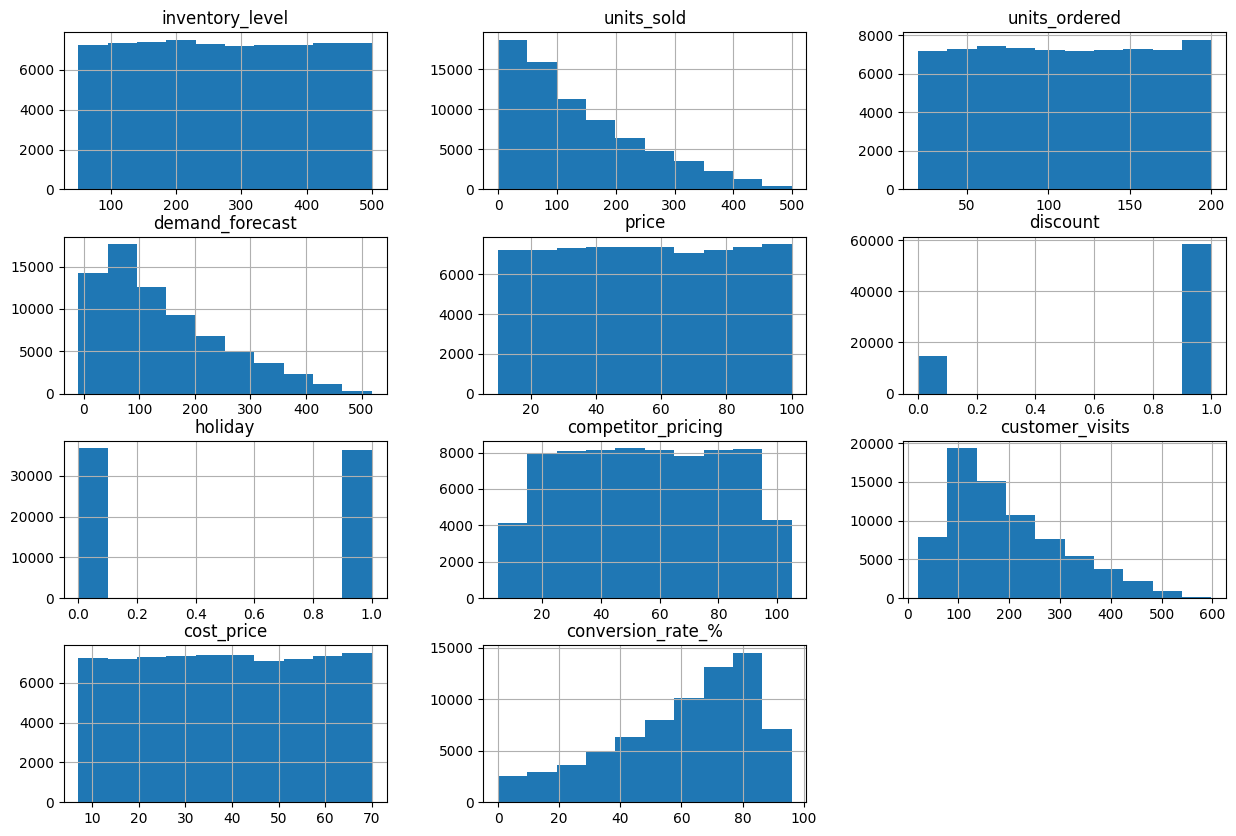

In [ ]:
df.hist(figsize=(15,10))
plt.show()

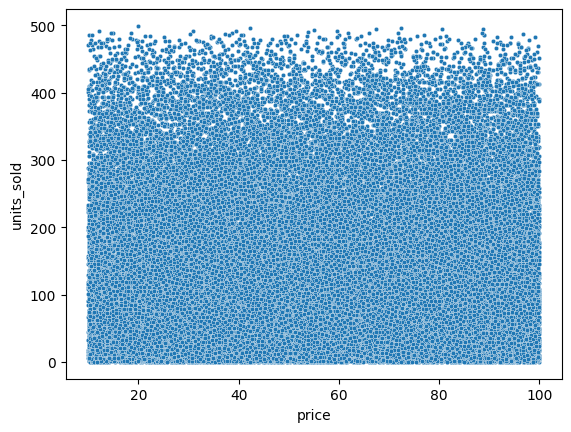

In [ ]:
sns.scatterplot(x="price", y="units_sold", data=df, s=10)
plt.show()

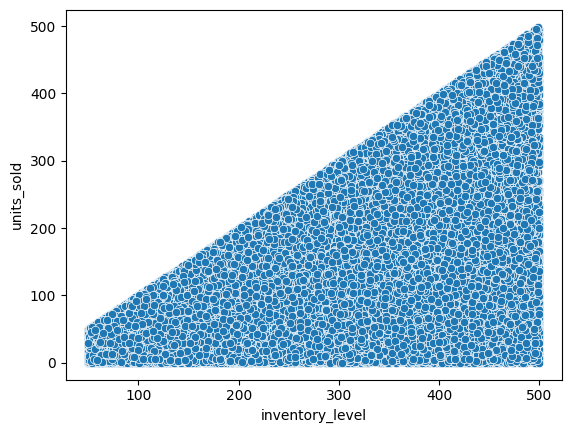

In [ ]:
sns.scatterplot(x="inventory_level", y="units_sold", data=df)
plt.show()

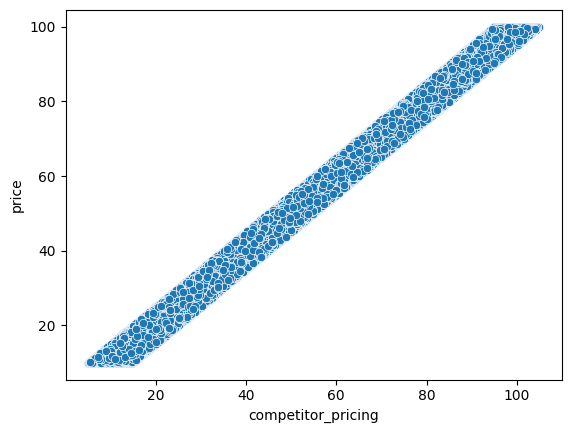

In [ ]:
sns.scatterplot(x="competitor_pricing", y="price", data=df)
plt.show()

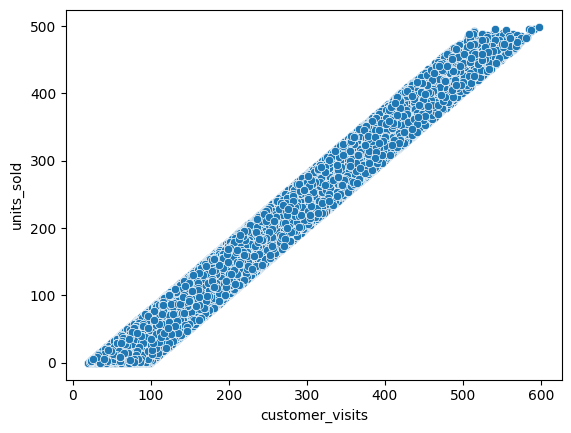

In [ ]:
sns.scatterplot(x="customer_visits", y="units_sold", data=df)
plt.show()

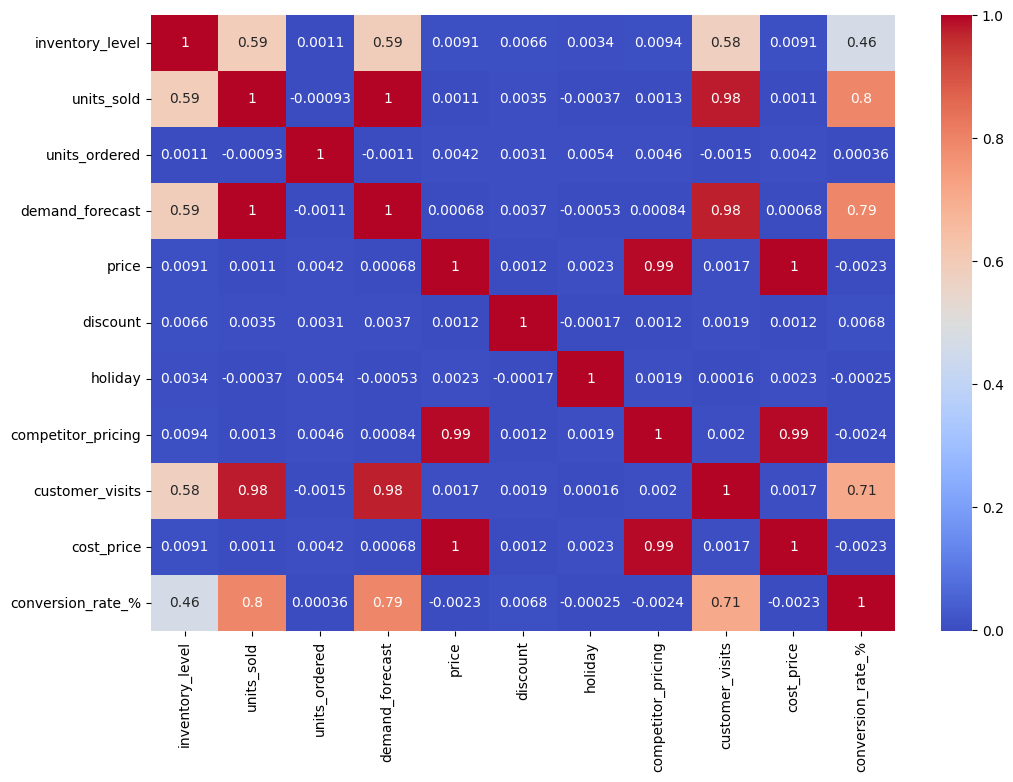

In [ ]:
plt.figure(figsize=(12,8))
df['date'] = pd.to_datetime(df['date'])
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

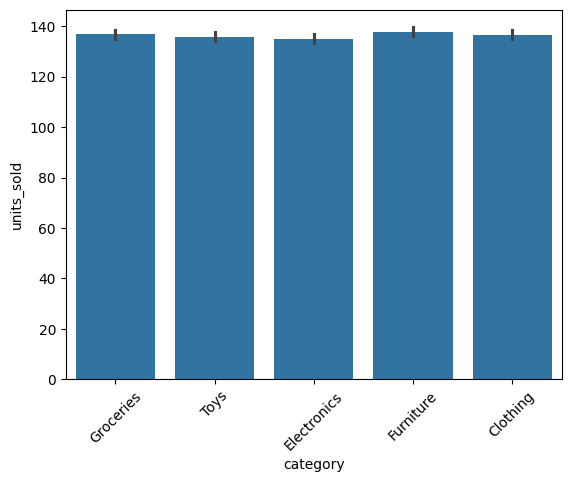

In [ ]:
sns.barplot(x="category", y="units_sold", data=df)
plt.xticks(rotation=45)
plt.show()

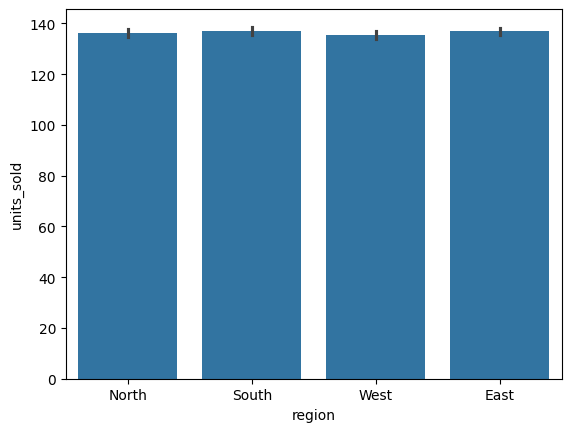

In [ ]:
sns.barplot(x="region", y="units_sold", data=df)
plt.show()

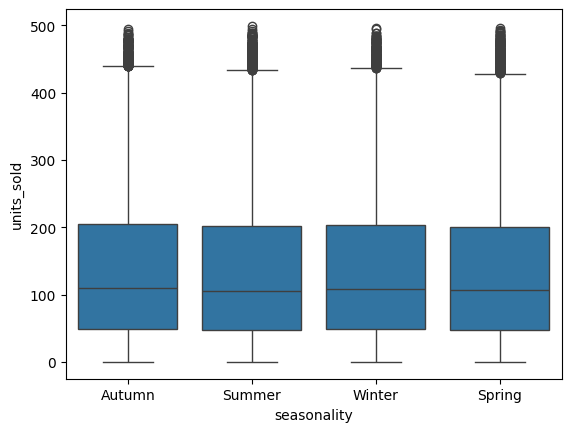

In [ ]:
sns.boxplot(x="seasonality", y="units_sold", data=df)
plt.show()

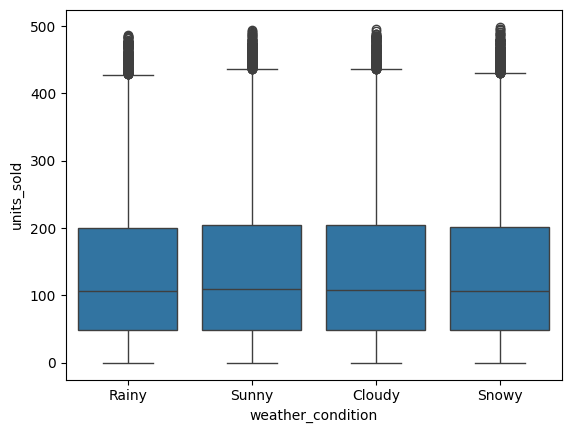

In [ ]:
sns.boxplot(x="weather_condition", y="units_sold", data=df)
plt.show()

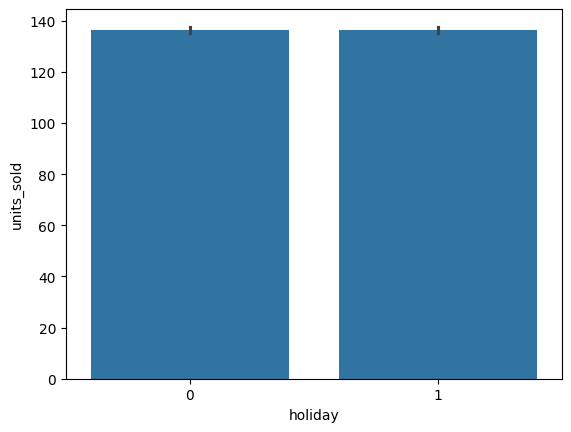

In [ ]:
sns.barplot(x="holiday", y="units_sold", data=df)
plt.show()

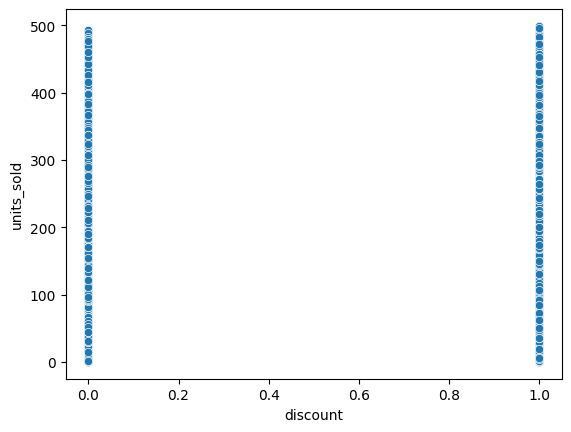

In [ ]:
sns.scatterplot(x="discount", y="units_sold", data=df)
plt.show()

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday',
       'competitor_pricing', 'seasonality', 'customer_visits', 'cost_price',
       'conversion_rate_%', 'profit_margin', 'discounted_price', 'revenue'],
      dtype='object')


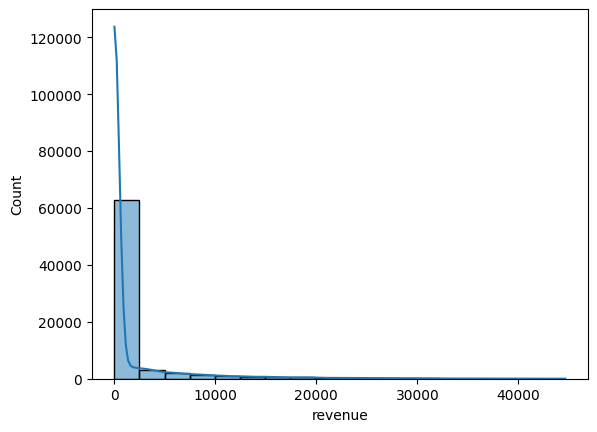

In [ ]:
df["discounted_price"] = df["price"] * (1 - df["discount"])
df["revenue"] = df["units_sold"] * df["discounted_price"]
sns.histplot(df["revenue"], kde=True)
print(df.columns)
plt.show()

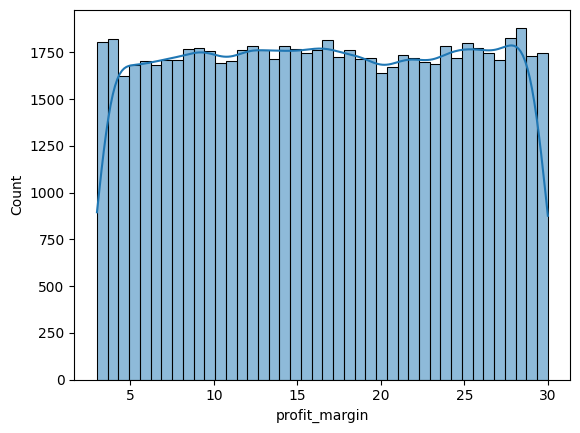

In [ ]:
df["profit_margin"] = df["price"] - df["cost_price"]
sns.histplot(df["profit_margin"], kde=True)
plt.show()

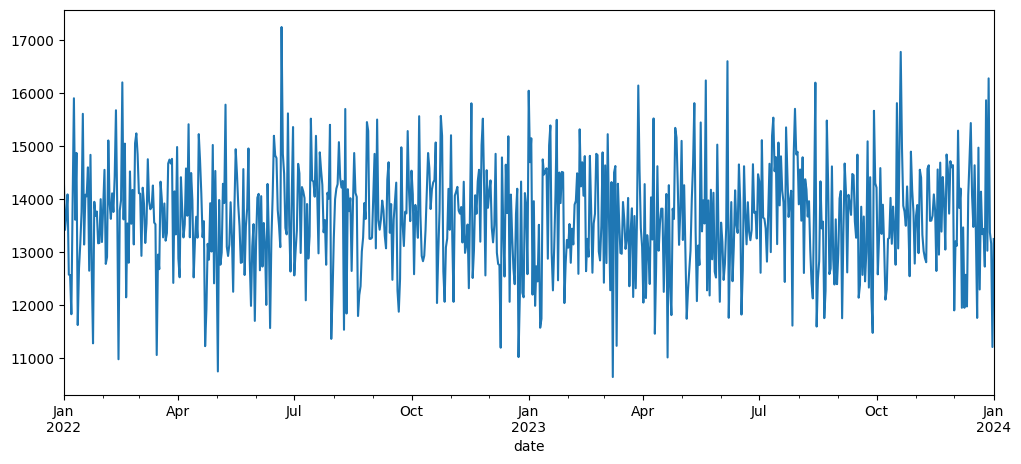

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df.groupby("date")["units_sold"].sum().plot(figsize=(12,5))
plt.show()

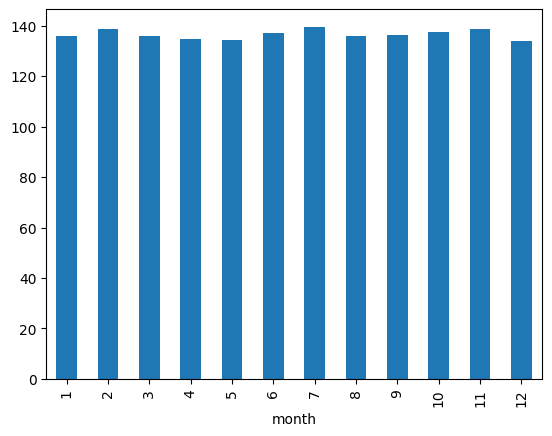

In [ ]:
df["month"] = df["date"].dt.month
df.groupby("month")["units_sold"].mean().plot(kind="bar")
plt.show()

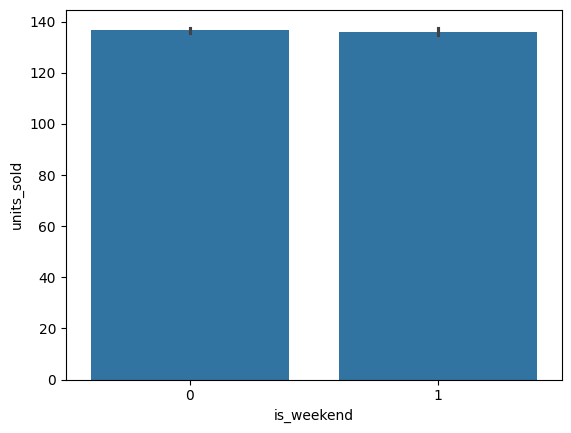

In [ ]:
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
sns.barplot(x="is_weekend", y="units_sold", data=df)
plt.show()

<Axes: xlabel='conversion_rate', ylabel='Count'>

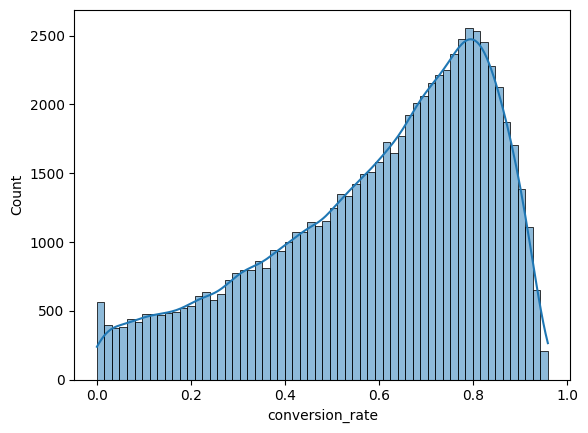

In [ ]:
df["conversion_rate"] = df["units_sold"] / (df["customer_visits"] + 1)
sns.histplot(df["conversion_rate"], kde=True)

<Axes: xlabel='inventory_pressure', ylabel='Count'>

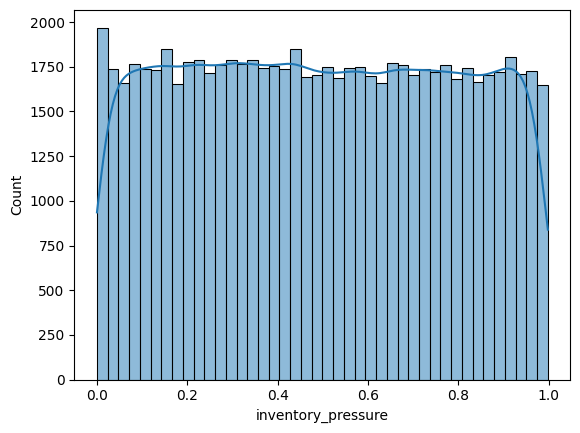

In [ ]:
df["inventory_pressure"] = df["units_sold"] / (df["inventory_level"] + 1)
sns.histplot(df["inventory_pressure"], kde=True)

<Axes: xlabel='competitor_gap', ylabel='Count'>

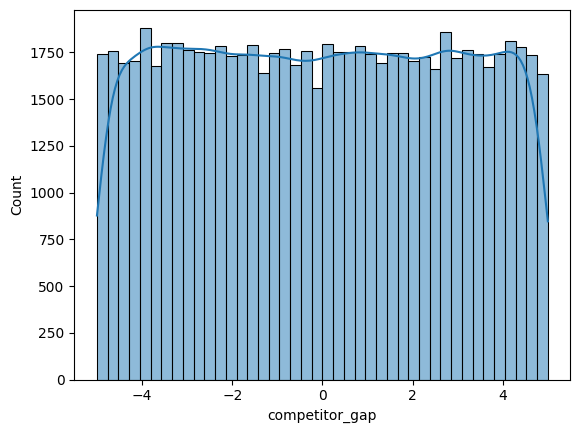

In [ ]:
df["competitor_gap"] = df["price"] - df["competitor_pricing"]
sns.histplot(df["competitor_gap"], kde=True)

<Axes: xlabel='demand_ratio', ylabel='Count'>

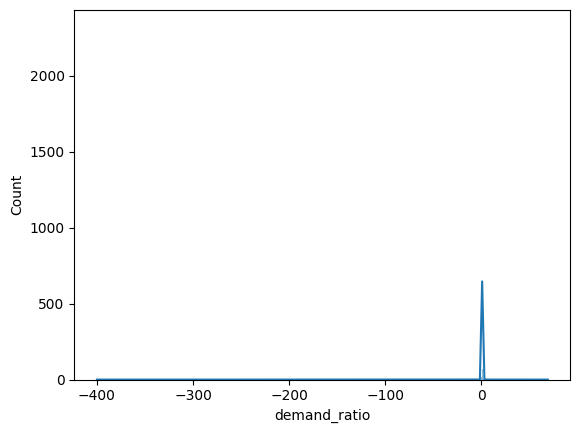

In [ ]:
df["demand_ratio"] = df["units_sold"] / (df["demand_forecast"] + 1)
sns.histplot(df["demand_ratio"], kde=True)

FEATURE ENGINEERING DATASET

In [ ]:
import pandas as pd
df = pd.read_csv("clean_dynamic_pricing_dataset.csv")

In [ ]:
df["profit_margin"] = df["price"] - df["cost_price"]

In [ ]:
df["margin_percent"] = (df["price"] - df["cost_price"]) / df["price"]

In [ ]:
df["demand_ratio"] = df["units_sold"] / (df["demand_forecast"] + 1)

In [ ]:
df["inventory_pressure"] = df["units_sold"] / (df["inventory_level"] + 1)

In [ ]:
df["competitor_gap"] = df["price"] - df["competitor_pricing"]

In [ ]:
df["discounted_price"] = df["price"] * (1 - df["discount"])

In [ ]:
df["revenue"] = df["units_sold"] * df["discounted_price"]

In [ ]:
df["conversion_rate"] = df["units_sold"] / (df["customer_visits"] + 1)

In [ ]:
df["price_demand_ratio"] = df["price"] / (df["units_sold"] + 1)

In [ ]:
df["stock_remaining"] = df["inventory_level"] - df["units_sold"]

In [ ]:
df["traffic_intensity"] = df["customer_visits"] / (df["inventory_level"] + 1)

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [ ]:
df.to_csv("feature_engineered_dataset.csv", index=False)